In [9]:
# coding: utf-8
""" demo using GREIT """
# Copyright (c) Benyuan Liu. All Rights Reserved.
# Distributed under the (new) BSD License. See LICENSE.txt for more info.
from __future__ import division, absolute_import, print_function

import numpy as np
import matplotlib.pyplot as plt

import pyeit.mesh as mesh
from pyeit.eit.fem import EITForward
import pyeit.eit.protocol as protocol
from pyeit.mesh.shape import thorax
import pyeit.eit.greit as greit
from pyeit.mesh.wrapper import PyEITAnomaly_Circle

In [10]:
""" 0. construct mesh """
n_el = 16  # nb of electrodes
use_customize_shape = False
if use_customize_shape:
    # Mesh shape is specified with fd parameter in the instantiation, e.g : fd=thorax
    mesh_obj = mesh.create(n_el, h0=0.1, fd=thorax)
else:
    mesh_obj = mesh.create(n_el, h0=0.1)

# extract node, element, alpha
pts = mesh_obj.node
tri = mesh_obj.element


In [11]:
""" 1. problem setup """
# this step is not needed, actually
# mesh_0 = mesh.set_perm(mesh_obj, background=1.0)

# test function for altering the 'permittivity' in mesh
anomaly = [
    PyEITAnomaly_Circle(center=[0.4, 0], r=0.1, perm=10.0),
    PyEITAnomaly_Circle(center=[-0.4, 0], r=0.1, perm=10.0),
    PyEITAnomaly_Circle(center=[0, 0.5], r=0.1, perm=0.1),
    PyEITAnomaly_Circle(center=[0, -0.5], r=0.1, perm=0.1),
]
mesh_new = mesh.set_perm(mesh_obj, anomaly=anomaly, background=1.0)
delta_perm = np.real(mesh_new.perm - mesh_obj.perm)


In [12]:
""" 2. FEM forward simulations """
# setup EIT scan conditions
protocol_obj = protocol.create(n_el, dist_exc=1, step_meas=1, parser_meas="std")

# calculate simulated data
fwd = EITForward(mesh_obj, protocol_obj)
v0 = fwd.solve_eit()
v1 = fwd.solve_eit(perm=mesh_new.perm)

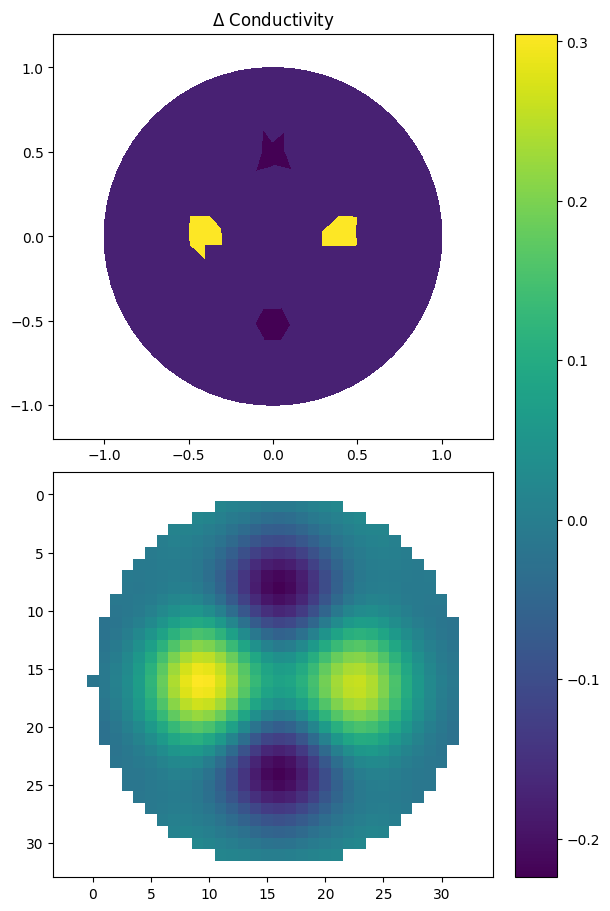

In [14]:
""" 3. Construct using GREIT """
eit = greit.GREIT(mesh_obj, protocol_obj)
eit.setup(p=0.50, lamb=0.01, perm=1, jac_normalized=True)
ds = eit.solve(v1, v0, normalize=True)
x, y, ds = eit.mask_value(ds, mask_value=np.nan)

# show alpha
fig, axes = plt.subplots(2, 1, constrained_layout=True, figsize=(6, 9))

ax = axes[0]
im = ax.tripcolor(pts[:, 0], pts[:, 1], tri, delta_perm, shading="flat")
ax.axis("equal")
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_title(r"$\Delta$ Conductivity")
# fig.set_size_inches(6, 4)

# plot
"""
imshow will automatically set NaN (bad values) to 'w',
if you want to manually do so

import matplotlib.cm as cm
cmap = cm.gray
cmap.set_bad('w', 1.)
plt.imshow(np.real(ds), interpolation='nearest', cmap=cmap)
"""
ax = axes[1]
im = ax.imshow(np.real(ds), interpolation="none", cmap=plt.cm.viridis)
ax.axis("equal")

fig.colorbar(im, ax=axes.ravel().tolist())
# fig.savefig('../doc/images/demo_greit.png', dpi=96)
plt.show()

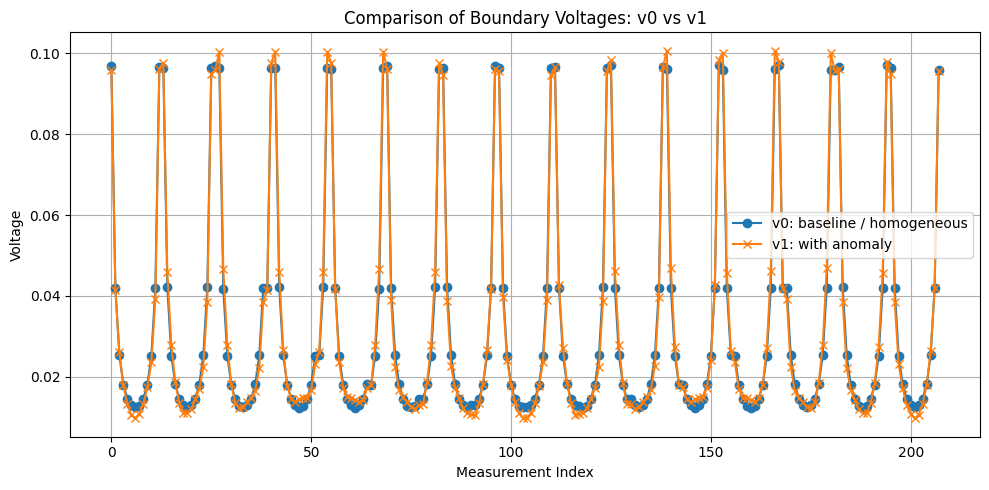

In [17]:
# Plot v0 and v1 in the same graph
plt.figure(figsize=(10, 5))

plt.plot(v0, marker='o', label='v0: baseline / homogeneous')
plt.plot(v1, marker='x', label='v1: with anomaly')

plt.title("Comparison of Boundary Voltages: v0 vs v1")
plt.xlabel("Measurement Index")
plt.ylabel("Voltage")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()